In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv(r"C:\Users\dell\Documents\#sneha imp\SQL\only projects\industrial_sensor_data.csv",parse_dates=["Timestamp"])

In [5]:
print(df.shape),
print(df.head()),
print(df.info()),
print(df.describe())

(500, 7)
          Timestamp Machine_ID Production_Line  Vibration_mm_s  Temperature_C  \
0  01-01-2025 08:00      M-104          Line-B            6.16          83.71   
1  01-01-2025 10:00      M-105          Line-C            4.23          66.88   
2  01-01-2025 12:00      M-103          Line-B            5.22          77.83   
3  01-01-2025 14:00      M-105          Line-C            3.73          77.66   
4  01-01-2025 16:00      M-105          Line-C            4.69          75.72   

   Output_Units  Downtime_Minutes  
0            41              27.9  
1            92               0.1  
2            97              20.8  
3            68               0.0  
4            82              12.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         500 non-null    object 
 1   Machine_ID        500 non-null    obje

In [6]:
#Missing Values
print(df.isnull().sum())

Timestamp           0
Machine_ID          0
Production_Line     0
Vibration_mm_s      0
Temperature_C       0
Output_Units        0
Downtime_Minutes    0
dtype: int64


In [7]:
# Duplicate Values
print("duplicates:",df.duplicated().sum())

duplicates: 0


In [8]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"],dayfirst=True)
df["Date"]=df["Timestamp"].dt.date
df["Hour"]=df["Timestamp"].dt.hour

In [9]:
#Risk Classification
def Risk_level(row):
    if row["Vibration_mm_s"]>=7 and row["Temperature_C"]>=85:
        return "Critical"
    elif row["Vibration_mm_s"]>5 and row["Temperature_C"]>=75:
        return "High"
    elif row["Vibration_mm_s"]>3 and row ["Temperature_C"]>=65:
        return "Medium"
    else:
        return "Normal"
df["Risk_level"]=df.apply(Risk_level,axis=1)
df.head()

,Timestamp,Machine_ID,Production_Line,Vibration_mm_s,Temperature_C,Output_Units,Downtime_Minutes,Date,Hour,Risk_level
0,2025-01-01 08:00:00,M-104,Line-B,6.16,83.71,41,27.9,2025-01-01,8,High
1,2025-01-01 10:00:00,M-105,Line-C,4.23,66.88,92,0.1,2025-01-01,10,Medium
2,2025-01-01 12:00:00,M-103,Line-B,5.22,77.83,97,20.8,2025-01-01,12,High
3,2025-01-01 14:00:00,M-105,Line-C,3.73,77.66,68,0.0,2025-01-01,14,Medium
4,2025-01-01 16:00:00,M-105,Line-C,4.69,75.72,82,12.2,2025-01-01,16,Medium


In [10]:
print(Risk_level({"Vibration_mm_s":8,"Temperature_C":75}))

High


In [11]:
# correlation Analysis
numeric_columns=[
    "Vibration_mm_s",
    "Temperature_C",
    "Output_Units",
    "Downtime_Minutes"
]
correlation=df[numeric_columns].corr()
print(correlation.round(2))

                  Vibration_mm_s  Temperature_C  Output_Units  \
Vibration_mm_s              1.00           0.70         -0.72   
Temperature_C               0.70           1.00         -0.68   
Output_Units               -0.72          -0.68          1.00   
Downtime_Minutes            0.87           0.77         -0.75   

                  Downtime_Minutes  
Vibration_mm_s                0.87  
Temperature_C                 0.77  
Output_Units                 -0.75  
Downtime_Minutes              1.00  


In [12]:
#Machine Analysis
machine_summary=(
    df.groupby("Machine_ID")
    .agg(
        Avg_Vibrtion=("Vibration_mm_s","mean"),
        Avg_Temeperature=("Temperature_C","mean"),
        Total_Output=("Output_Units","sum"),
        Avg_Output=("Output_Units","mean"),
        Total_Downtime=("Downtime_Minutes","sum"),
        Avg_Downtime=("Downtime_Minutes","mean")
    ).round(2)
)
print(machine_summary)

            Avg_Vibrtion  Avg_Temeperature  Total_Output  Avg_Output  \
Machine_ID                                                             
M-101               4.51             76.59          8309       76.23   
M-102               4.51             75.67          7400       77.89   
M-103               4.35             76.05          7243       79.59   
M-104               4.45             75.76          8629       77.04   
M-105               5.00             76.69          7052       75.83   

            Total_Downtime  Avg_Downtime  
Machine_ID                                
M-101               1408.4         12.92  
M-102               1157.4         12.18  
M-103               1018.7         11.19  
M-104               1322.4         11.81  
M-105               1361.3         14.64  


## Visualization

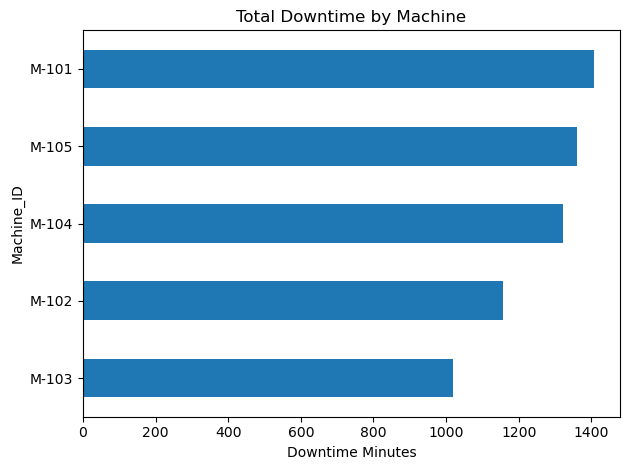

In [13]:
#Dwontime by Machine
machine_summary["Total_Downtime"].sort_values().plot(kind="barh")
plt.title("Total Downtime by Machine")
plt.xlabel("Downtime Minutes")
plt.tight_layout()
plt.show()

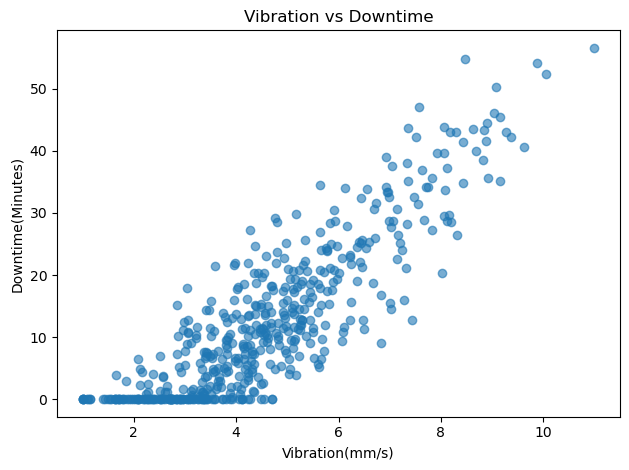

In [14]:
#Vibration vs downtime
plt.scatter(
    df["Vibration_mm_s"],
    df["Downtime_Minutes"],
    alpha=0.6
)
plt.title("Vibration vs Downtime")
plt.xlabel("Vibration(mm/s)")
plt.ylabel("Downtime(Minutes)")
plt.tight_layout()
plt.show()

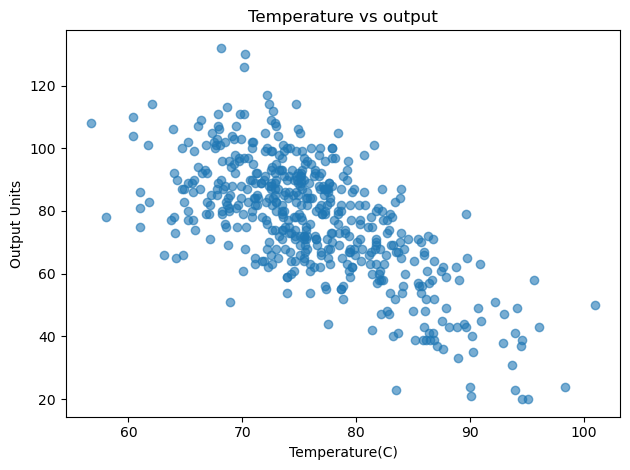

In [16]:
#Temperature vs output
plt.scatter(
    df["Temperature_C"],
    df["Output_Units"],
    alpha=0.6
)
plt.title("Temperature vs output")
plt.xlabel("Temperature(C)")
plt.ylabel("Output Units")
plt.tight_layout()
plt.show()